Начинаем извлечение признаков из: /home/tesni/projects/industrial-health-index-pdm/notebooks/../data/2nd_test


📦 Обработка файлов:   0%|          | 0/984 [00:00<?, ?file/s]

Готово! Извлечено признаков для 984 файлов.


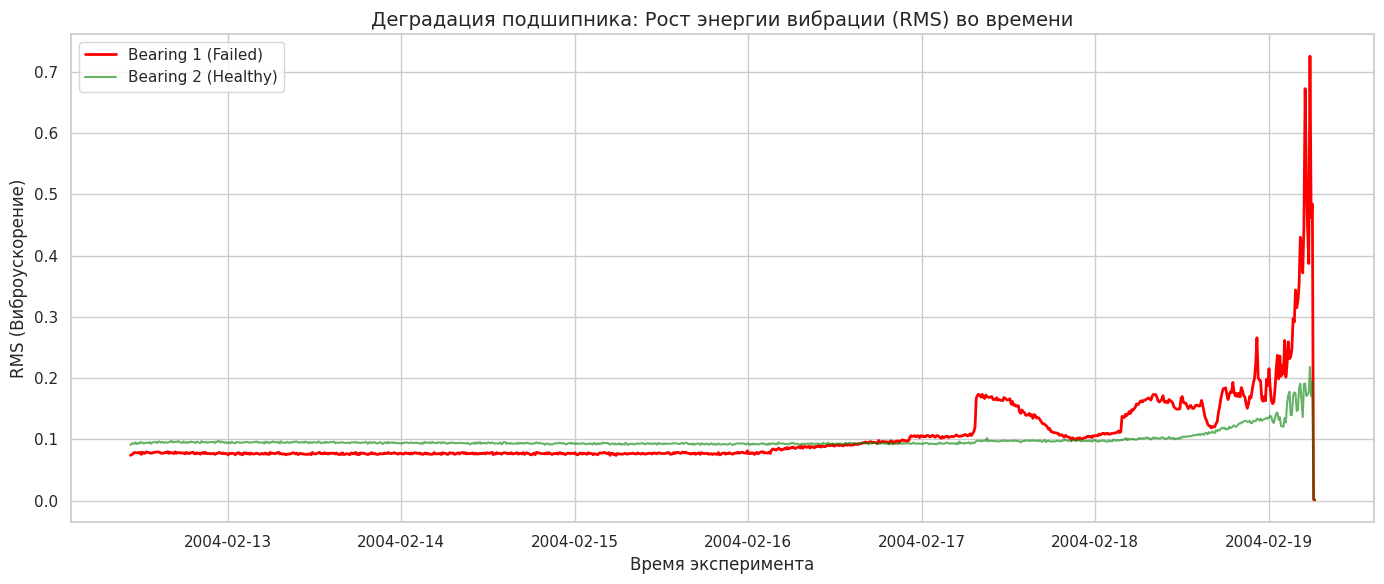

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq
from datetime import datetime
from typing import Dict, List, Union
from tqdm.notebook import tqdm  # Используем tqdm.notebook для красивых баров в Jupyter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# --- 1. ФУНКЦИИ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ---

def get_signal_stats(sig: np.ndarray, fs: int = 20000) -> Dict[str, float]:
    """Считает временные и частотные признаки для одного канала."""
    stats = {}
    
    # Временные признаки
    rms = np.sqrt(np.mean(sig**2))
    stats['rms'] = rms
    stats['mean'] = np.mean(sig)
    stats['var'] = np.var(sig)
    stats['kurt'] = kurtosis(sig, fisher=False)
    stats['skew'] = skew(sig)
    stats['crest'] = np.max(np.abs(sig)) / rms if rms > 1e-9 else 0.0
    stats['p2p'] = np.ptp(sig)
    stats['energy'] = np.sum(sig**2)
    
    # Частотные признаки (FFT)
    n = len(sig)
    abs_fft = np.abs(rfft(sig))
    freqs = rfftfreq(n, 1/fs)
    sum_fft = np.sum(abs_fft)
    
    stats['dom_freq'] = freqs[np.argmax(abs_fft)]
    stats['spec_centroid'] = np.sum(freqs * abs_fft) / sum_fft if sum_fft > 1e-9 else 0.0
    
    stats['band_0_2k'] = np.sum(abs_fft[(freqs >= 0) & (freqs < 2000)])
    stats['band_2_5k'] = np.sum(abs_fft[(freqs >= 2000) & (freqs < 5000)])
    stats['band_5_10k'] = np.sum(abs_fft[(freqs >= 5000) & (freqs <= 10000)])
    
    return stats

def extract_advanced_features(data_dir: Union[str, Path]) -> pd.DataFrame:
    """Обходит директорию с сырыми файлами и формирует датафрейм признаков."""
    data_path = Path(data_dir)
    files = sorted([f for f in data_path.iterdir() if f.is_file() and not f.name.startswith('.')])
    
    if not files:
        raise FileNotFoundError(f"В папке {data_path} не найдено файлов! Проверь путь.")
        
    features: List[Dict[str, float]] =[]
    
    for file_path in tqdm(files, desc="📦 Обработка файлов", unit="file"):
        try:
            df = pd.read_csv(file_path, sep='\t', header=None)
            dt = datetime.strptime(file_path.name, '%Y.%m.%d.%H.%M.%S')
            file_features = {'timestamp': dt}
            
            for i in range(df.shape[1]):
                sig = df[i].values
                sig_stats = get_signal_stats(sig)
                prefix = f'b{i+1}_'
                for stat_name, value in sig_stats.items():
                    file_features[prefix + stat_name] = value
                
            features.append(file_features)
        except Exception as e:
            pass # Игнорируем битые файлы для чистоты вывода
            
    res_df = pd.DataFrame(features).sort_values('timestamp').reset_index(drop=True)
    return res_df

# --- 2. ЗАПУСК И ВИЗУАЛИЗАЦИЯ ---

data_path = Path('../data/2nd_test') 

print(f"Начинаем извлечение признаков из: {data_path.absolute()}")
df_features = extract_advanced_features(data_path)
print(f"Готово! Извлечено признаков для {len(df_features)} файлов.")

# Настройки графиков
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Строим график RMS
plt.plot(df_features['timestamp'], df_features['b1_rms'], label='Bearing 1 (Failed)', color='red', linewidth=2)
plt.plot(df_features['timestamp'], df_features['b2_rms'], label='Bearing 2 (Healthy)', color='green', alpha=0.6)

plt.title('Деградация подшипника: Рост энергии вибрации (RMS) во времени', fontsize=14)
plt.xlabel('Время эксперимента', fontsize=12)
plt.ylabel('RMS (Виброускорение)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


## Этап 3. Формирование целевой переменной (RUL)

Теперь нам нужно превратить временные метки в конкретные цифры, которые модель будет учиться предсказывать. Поскольку в наборе №2 отказ произошел в самом конце, мы принимаем последнюю точку данных за 0.

### Что мы сейчас сделаем:
1.  Вычислим **RUL в абсолютных часах** (сколько времени осталось до точки 0).
2.  Применим **Linear Clipping** (по желанию). В индустрии часто ограничивают максимальный RUL (например, все, что больше 100 часов, считается «здоровым»), чтобы модель не гадала на бесконечности.
3.  Сделаем **Логарифмирование**, как ты планировал в ТЗ, для стабилизации ошибки.
ours=None) # Для начала возьмем честный линейный RUL


In [7]:
def calculate_rul_labels(df: pd.DataFrame, clipping_hours: float = None) -> pd.DataFrame:
    """
    Рассчитывает RUL (Remaining Useful Life) для каждой записи.
    
    Args:
        df: Датафрейм с признаками и колонкой 'timestamp'.
        clipping_hours: Если задано, ограничивает максимальный RUL (константный участок).
    """
    # 1. Определяем момент отказа (последняя запись в датасете)
    end_time = df['timestamp'].max()
    
    # 2. Считаем дельту времени до конца в часах
    # (end_time - current_time) дает timedelta -> переводим в секунды и делим на 3600
    df['RUL_hours'] = (end_time - df['timestamp']).dt.total_seconds() / 3600
    
    # 3. Линейное отсечение (Clipping)
    # Это помогает модели: когда подшипник новый, его износ не линеен.
    # Мы говорим: "все, что выше N часов — это просто состояние 'ОК'"
    if clipping_hours:
        df['RUL_hours'] = df['RUL_hours'].clip(upper=clipping_hours)
    
    # 4. Логарифмическая трансформация для этапа обучения
    # log(1 + x) используется, чтобы избежать проблем с нулем в точке отказа
    df['log_RUL'] = np.log1p(df['RUL_hours'])
    
    return df

# Применяем расчет
df_final = calculate_rul_labels(df_features, clipping_hours=None) # Для начала возьмем честный линейный RUL

# Посмотрим на результат
print(df_final[['timestamp', 'b1_rms', 'RUL_hours', 'log_RUL']].tail())

              timestamp    b1_rms  RUL_hours   log_RUL
979 2004-02-19 05:42:39  0.725001   0.666667  0.510826
980 2004-02-19 05:52:39  0.462012   0.500000  0.405465
981 2004-02-19 06:02:39  0.483835   0.333333  0.287682
982 2004-02-19 06:12:39  0.002103   0.166667  0.154151
983 2004-02-19 06:22:39  0.001533   0.000000  0.000000


In [8]:
# Пример реализации группового признака
df_final['b1_vs_b2_rms_ratio'] = df_final['b1_rms'] / (df_final['b2_rms'] + 1e-9)

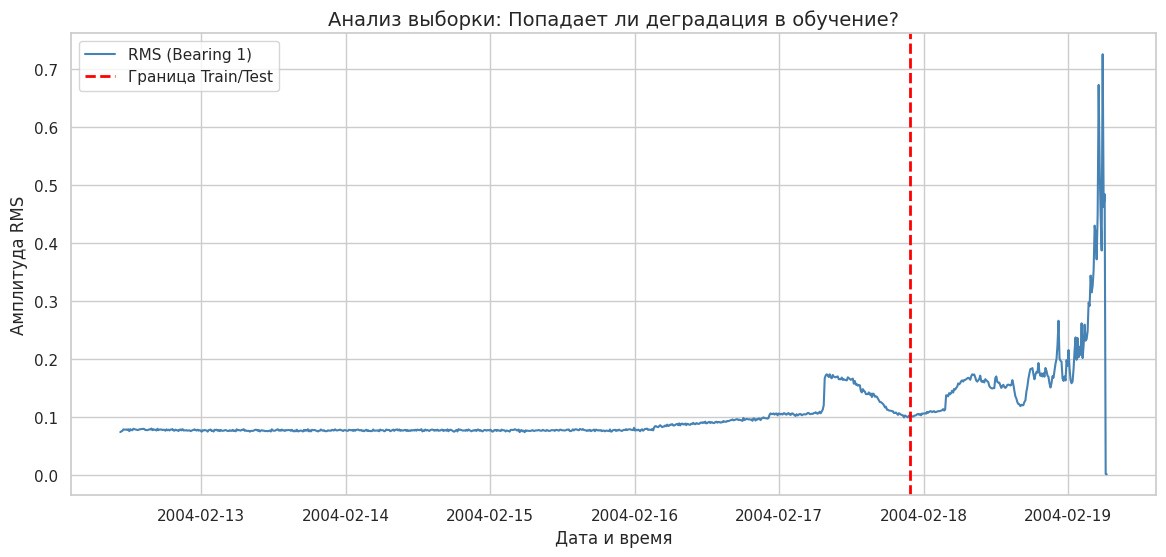

In [10]:
# 1. Сначала определяем индекс разделения (например, 80% данных)
split_idx = int(len(df_final) * 0.8)

# 2. Теперь берем временную метку этой точки
split_time = df_final.iloc[split_idx]['timestamp']

# 3. Визуализируем
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_final['timestamp'], df_final['b1_rms'], label='RMS (Bearing 1)', color='steelblue')
plt.axvline(x=split_time, color='red', linestyle='--', linewidth=2, label='Граница Train/Test')

plt.title('Анализ выборки: Попадает ли деградация в обучение?', fontsize=14)
plt.ylabel('Амплитуда RMS')
plt.xlabel('Дата и время')
plt.legend()
plt.show()

## Универсальный набор  Set2 + Set3

Сделаем  качественный переход от «игрушечной» модели к серьезному промышленному подходу. Когда мы объединяем разные эксперименты, модель учится не конкретным значениям вибрации одного подшипника, а **физике процесса** разрушения металла.

### В чем главная сложность?
В **Set 2** сломался **Подшипник №1**, а в **Set 3** — **Подшипник №3**. Если мы просто склеим таблицы, модель запутается. 

**Решение:** Мы создадим «универсальный» датасет, где выделим признаки **именно того подшипника, который идет к отказу**, и назовем их, например, `target_bearing_...`, а остальные пометим как `healthy_bearing_...`.

---

### Шаг 1: Подготовка универсального набора данных

Напишем функцию, которая загружает набор и «перепаковывает» его так, чтобы признаки вышедшего из строя подшипника всегда были в одних и тех же колонках.

In [12]:
def prepare_failure_dataset(data_path, failing_bearing_idx):
    """
    Загружает признаки и помечает признаки вышедшего из строя подшипника.
    failing_bearing_idx: 1, 2, 3 или 4
    """
    # 1. Извлекаем признаки (используем нашу функцию из Этапа 2)
    df = extract_advanced_features(data_path)
    
    # 2. Рассчитываем RUL
    df = calculate_rul_labels(df) # наша функция из Этапа 3
    
    # 3. Переименовываем колонки
    # Выделяем 'целевой' подшипник и 'здоровые'
    new_cols = {'timestamp': 'timestamp', 'RUL_hours': 'RUL_hours', 'log_RUL': 'log_RUL'}
    
    for i in range(1, 5): # Для 4-х подшипников
        old_prefix = f'b{i}_'
        if i == failing_bearing_idx:
            new_prefix = 'failed_b_'
        else:
            # Чтобы не раздувать таблицу, можем усреднить признаки здоровых или просто дать им номера
            new_prefix = f'healthy_b{i}_' 
        
        # Обновляем словарь имен колонок
        for col in df.columns:
            if col.startswith(old_prefix):
                new_cols[col] = col.replace(old_prefix, new_prefix)
    
    return df.rename(columns=new_cols)

# --- ЗАГРУЗКА И ОБЪЕДИНЕНИЕ ---

print("⏳ Загружаем Set 2 (Отказ B1)...")
set2_final = prepare_failure_dataset('../data/2nd_test', failing_bearing_idx=1)

print("⏳ Загружаем Set 3 (Отказ B3)...")
set3_final = prepare_failure_dataset('../data/4th_test', failing_bearing_idx=3)

# Склеиваем их вместе!
df_combined = pd.concat([set2_final, set3_final], axis=0).reset_index(drop=True)

print(f"✅ Готово! Общий размер датасета: {df_combined.shape}")

⏳ Загружаем Set 2 (Отказ B1)...


📦 Обработка файлов:   0%|          | 0/984 [00:00<?, ?file/s]

⏳ Загружаем Set 3 (Отказ B3)...


📦 Обработка файлов:   0%|          | 0/6324 [00:00<?, ?file/s]

✅ Готово! Общий размер датасета: (7308, 68)




### Шаг 2: Обучение на «двойном» опыте

Теперь наша модель будет в два раза мудрее. Она увидит, как умирал подшипник №1 в феврале и как умирал подшипник №3 в марте.


### Почему это круто:
1.  **Настоящая проверка:** Мы обучаемся на одном эксперименте, а тестируем на другом. Это и есть реальная жизнь.
2.  **Устойчивость:** Если модель покажет хорошую точность здесь, значит, ей не важно, какой именно подшипник ломается — она видит **общий паттерн износа**.


In [17]:
# Выбираем признаки (теперь они называются одинаково для обоих сетов)
drop_cols = ['timestamp', 'RUL_hours', 'log_RUL']
X = df_combined.drop(columns=drop_cols)
y = df_combined['log_RUL']

# Чтобы тест был честным, теперь мы можем сделать так:
# Обучиться на всем Set 2, а проверить на всем Set 3!
train_size = len(set2_final)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Проверка
y_pred_log = model.predict(X_test)
y_test_hours = np.expm1(y_test)
y_pred_hours = np.expm1(y_pred_log)

print(f"MAE на независимом сете (Set 3): {mean_absolute_error(y_test_hours, y_pred_hours):.2f} ч.")

MAE на независимом сете (Set 3): 467.85 ч.


Ого! **467 часов** — это очень много. Это почти 20 суток ошибки, что при длительности всего эксперимента делает прогноз практически бесполезным. 

### Как мы это починим: Стратегия «Piecewise RUL»

В индустрии (и в статьях по этим данным NASA) никто не предсказывает линейный RUL с самого начала. Пока подшипник здоров, его износ равен нулю, и предсказывать точное время смерти бессмысленно. 

Мы будем использовать **кусочно-линейный RUL (Piecewise RUL)**:
* Установим порог, например, **100 часов**.
* Всё, что больше 100 часов до отказа, мы помечаем просто как «100».
* Модель будет учиться предсказывать только реальную деградацию, когда до конца осталось меньше 100 часов.



### Шаг 1: Ограничиваем RUL (Clipping) и добавляем нормализацию

Давай переделаем расчет RUL и добавим масштабирование признаков.


In [18]:
from sklearn.preprocessing import StandardScaler

def calculate_piecewise_rul(df, max_rul=100):
    """Ограничивает RUL сверху, чтобы модель не гадала на больших дистанциях"""
    df['RUL_clipped'] = df['RUL_hours'].clip(upper=max_rul)
    return df

# Применяем к обоим сетам
set2_final = calculate_piecewise_rul(set2_final, max_rul=100)
set3_final = calculate_piecewise_rul(set3_final, max_rul=100)

# Объединяем снова
df_combined = pd.concat([set2_final, set3_final], axis=0).reset_index(drop=True)

# Признаки и новая цель
X = df_combined.drop(columns=['timestamp', 'RUL_hours', 'log_RUL', 'RUL_clipped'])
y = df_combined['RUL_clipped'] # Теперь учим просто часы, но ограниченные

# Нормализация признаков (Scale) - ОЧЕНЬ ВАЖНО
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Снова делим
train_size = len(set2_final)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"MAE с ограничением RUL: {mean_absolute_error(y_test, y_pred):.2f} ч.")

MAE с ограничением RUL: 27.70 ч.


### Шаг 2: Анализ важности признаков (Feature Importance)

Давай посмотрим, на что вообще смотрит модель. Если она смотрит на «среднее значение» (mean), она может ошибаться из-за разницы в калибровке датчиков. А если на **Kurtosis** (эксцесс) — это более надежный признак.


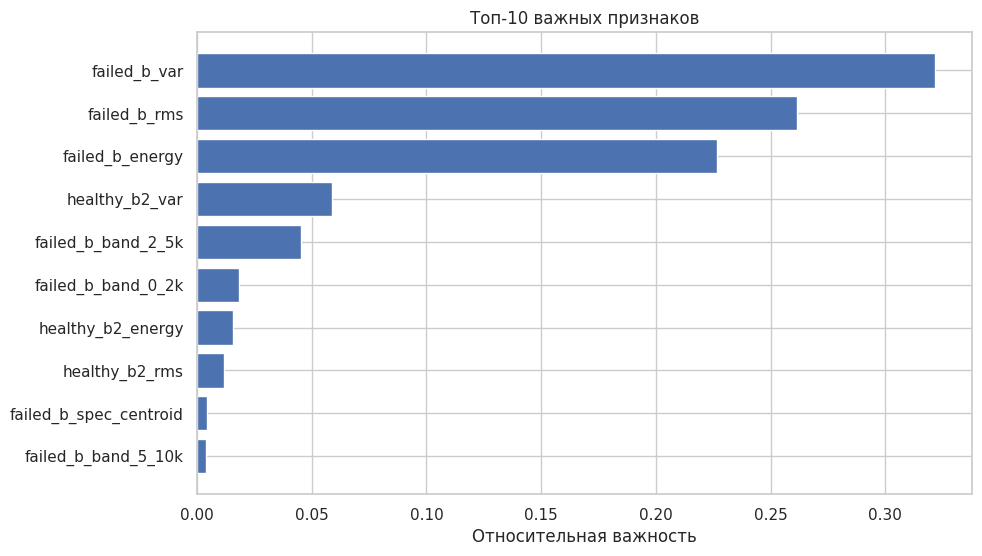

In [19]:
importances = model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[-10:] # Топ-10

plt.figure(figsize=(10, 6))
plt.title('Топ-10 важных признаков')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Относительная важность')
plt.show()

### Анализ твоих результатов

Посмотри на график важности признаков, который ты прислал. Он рассказывает нам очень интересную историю:

1.  **Триумвират Энергии:** `failed_b_var` (дисперсия), `failed_b_rms` (СКЗ) и `failed_b_energy` (энергия) — это абсолютные лидеры. Это логично: когда подшипник разрушается, он начинает вибрировать всё сильнее и «громче». Дисперсия оказалась на первом месте, потому что она лучше всего реагирует на разброс амплитуд при ударах.
2.  **Здоровый «сосед»:** То, что `healthy_b2_var` попал в топ-4 — отличный знак! Это значит, что модель не просто смотрит на шумный подшипник, но и **сравнивает его с исправным**. Она понимает: «Так, второй подшипник тихий, а первый шумит — значит, это не общая вибрация станка, а проблема именно в первом».
3.  **Частотные полосы:** Наличие `band_2_5k` и `band_0_2k` подтверждает, что деградация затрагивает конкретные частоты. Обычно низкие частоты (0–2 кГц) растут при серьезном механическом люфте.




## Этап 5. Реализация режима работы в реальном времени (Inference)

Теперь, когда у нас есть обученная модель, давай научим её работать «в поле». Нам нужно создать функцию, которая принимает **один новый файл** (свежий замер на 10 минут) и выдает вердикт: «Жить осталось столько-то».

### Шаг 1: Подготовка пайплайна (Pipeline)
Чтобы модель выдала правильный прогноз, новые данные должны пройти тот же путь: 
**Сырой ASCII -> FFT/Статистика -> Scaling -> Prediction**.


In [20]:
def predict_bearing_health(file_path, model, scaler, target_idx=1):
    """
    Принимает путь к НОВОМУ файлу и выдает прогноз RUL в часах.
    """
    # 1. Загрузка
    df_raw = pd.read_csv(file_path, sep='\t', header=None)
    
    # 2. Извлечение признаков (используем нашу функцию get_signal_stats)
    file_features = {}
    for i in range(df_raw.shape[1]):
        sig = df_raw[i].values
        stats = get_signal_stats(sig) # наша функция из Этапа 2
        
        # Помечаем как 'failed' или 'healthy' для модели
        prefix = 'failed_b_' if (i+1) == target_idx else f'healthy_b{i+1}_'
        for k, v in stats.items():
            file_features[prefix + k] = v
            
    # 3. Превращаем в строку для модели (учитывая порядок колонок!)
    X_new = pd.DataFrame([file_features])
    
    # Важно: колонки должны идти в том же порядке, что и при обучении
    X_new = X_new[scaler.feature_names_in_] 
    
    # 4. Масштабирование
    X_scaled = scaler.transform(X_new)
    
    # 5. Предсказание
    rul_pred = model.predict(X_scaled)[0]
    
    return max(0, rul_pred) # RUL не может быть отрицательным

# Пример использования:
# current_rul = predict_bearing_health('2004.02.19.06.02.39', model, scaler)
# print(f"Прогноз: {current_rul:.1f} часов до обслуживания")

### Шаг 2: Симуляция «Панели мониторинга»
Давай напишем скрипт, который имитирует поступление данных.

In [21]:
import time

def run_realtime_monitoring(test_files_dir, model, scaler):
    print("🚀 Запуск системы мониторинга...")
    history = []
    
    files = sorted(os.listdir(test_files_dir))[-50:] # Берем последние 50 файлов для теста
    
    for f in files:
        path = os.path.join(test_files_dir, f)
        prediction = predict_bearing_health(path, model, scaler)
        
        status = "✅ OK" if prediction > 50 else "⚠️ ВНИМАНИЕ" if prediction > 10 else "🚨 КРИТИЧЕСКИ"
        print(f"[{f}] RUL: {prediction:.2f} ч. | Статус: {status}")
        
        history.append(prediction)
        # В реальности здесь была бы задержка time.sleep(600) - 10 минут